# Импорт библиотек

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import cv2 as cv
import random

Загрузка изображения

In [2]:
# Загрузка изображений
print("="*60)
print("ЛАБОРАТОРНАЯ РАБОТА №2. ВИЗУАЛЬНАЯ ОДОМЕТРИЯ")
print("="*60)

# Загружаем изображения
img_paths = ['21.jpg', '22.jpg', '23.jpg', '24.jpg', '25.jpg', '26.jpg']
images_gray = []
target_size = (320, 240)  # Уменьшаем размер для ускорения

for i, path in enumerate(img_paths):
    img = cv.imread(path)
    if img is None:
        print(f"❌ Ошибка: не удалось загрузить {path}")
    else:
        img_resized = cv.resize(img, target_size)
        gray = cv.cvtColor(img_resized, cv.COLOR_BGR2GRAY)
        images_gray.append(gray)
        print(f"✅ Загружено {path}, размер: {gray.shape}")

if len(images_gray) < 2:
    print("❌ Ошибка: недостаточно изображений для выполнения работы")
    exit()

print(f"\n📊 Всего загружено: {len(images_gray)} изображений")
print("-"*60)

print("🔍 ШАГ 1: Детектирование ключевых точек (Harris Corner Detector)")
print("-"*60)

# Параметры
windowSize = 5

ЛАБОРАТОРНАЯ РАБОТА №2. ВИЗУАЛЬНАЯ ОДОМЕТРИЯ
✅ Загружено 21.jpg, размер: (240, 320)
✅ Загружено 22.jpg, размер: (240, 320)
✅ Загружено 23.jpg, размер: (240, 320)
✅ Загружено 24.jpg, размер: (240, 320)
✅ Загружено 25.jpg, размер: (240, 320)
✅ Загружено 26.jpg, размер: (240, 320)

📊 Всего загружено: 6 изображений
------------------------------------------------------------
🔍 ШАГ 1: Детектирование ключевых точек (Harris Corner Detector)
------------------------------------------------------------


# ШАГ 1: Детектирование ключевых точек и вычисление SIFT дескрипторов

In [3]:
def convolution(image, window):
    """Свертка изображения с ядром"""
#Вычисляет отступ start от краев изображения, чтобы ядро помещалось полностью.
    start = int((windowSize-1)/2)
    result = np.zeros((image.shape))
#image.shape[0] — высота изображения), чтобы избежать выхода за границы при свертке.
    for i in range(start, image.shape[0]-start):
        for j in range(start, image.shape[1]-start):
            result[i,j] = np.sum(image[i-start:i+start+1, j-start:j+start+1] * window)
    return result

In [4]:
def local_max(e, window):
    """Поиск локальных максимумов"""
    start = int((windowSize-1)/2)
#Инициализирует пустой словарь corner для хранения локальных максимумов: ключ — значение пикселя, значение — список координат [x, y]
    corner = dict()
    for i in range(start, e.shape[0]-start):
        for j in range(start, e.shape[1]-start):
#Извлекает локальное окно размером windowSize×windowSize вокруг пикселя (i,j).
            x = e[i-start:i+start+1, j-start:j+start+1]
#e[i][j] == np.max(x) — центральный пиксель является строгим максимумом в окне
            if e[i][j] == np.max(x) and e[i][j] > 0:
#Сохраняет координаты: [j, i] (x=столбец, y=строка). Перезаписывает при совпадении значений (остается последнее).
                corner[e[i][j]] = [j, i]  # x, y координаты
    return corner

In [7]:


def corner_detect(image, nCorners, windowSize):
    """Детектирование углов методом Харриса"""
#Инициализирует пустой список для хранения координат найденных углов.
    corners = []
    gauss_img = cv.GaussianBlur(image, (5,5), 3)
#Вычисляет градиенты по y и x координатам изображения
    dy, dx = np.gradient(gauss_img.astype(np.float64))
#Создает усредняющее окно (все элементы = 1) размером windowSize×windowSize
    window = np.ones((windowSize, windowSize))
#Вычисляют элементы матрицы автокорреляции: c_xx — свертка Ix² 

    c_xx = convolution(dx*dx, window)
    c_yy = convolution(dy*dy, window)
    c_xy = convolution(dx*dy, window)
#Создает нулевой массив для откликов углов того же размера.
    e = np.zeros((gauss_img.shape))
# цикл по пикселям
    for i in range(gauss_img.shape[0]):
        for j in range(gauss_img.shape[1]):
#Формирует 2×2 матрицу автокорреляции C   
            c = np.array([[c_xx[i][j], c_xy[i][j]], 
                          [c_xy[i][j], c_yy[i][j]]])
#Вычисляет собственные значения λ1, λ2
            l, v = np.linalg.eig(c)
#Отклик угла e[i,j] = min(λ1, λ2) (характер угла при больших положительных значениях)
            e[i][j] = np.min(l)
    
    corner_dict = local_max(e, windowSize)
    
    # Сортируем и берем лучшие
    sorted_keys = sorted(corner_dict.keys(), reverse=True)
    for key in sorted_keys[:nCorners]:
        corners.append(corner_dict[key])
    
    return np.array(corners)

# Детектируем углы
all_corners = []
for i, img in enumerate(images_gray):
    corners = corner_detect(img, 30, windowSize)
    all_corners.append(corners)
    print(f"   Изображение {i+1}: найдено {len(corners)} ключевых точек")


   Изображение 1: найдено 30 ключевых точек
   Изображение 2: найдено 30 ключевых точек
   Изображение 3: найдено 30 ключевых точек
   Изображение 4: найдено 30 ключевых точек
   Изображение 5: найдено 30 ключевых точек
   Изображение 6: найдено 30 ключевых точек


## ВИЗУАЛИЗАЦИЯ 1

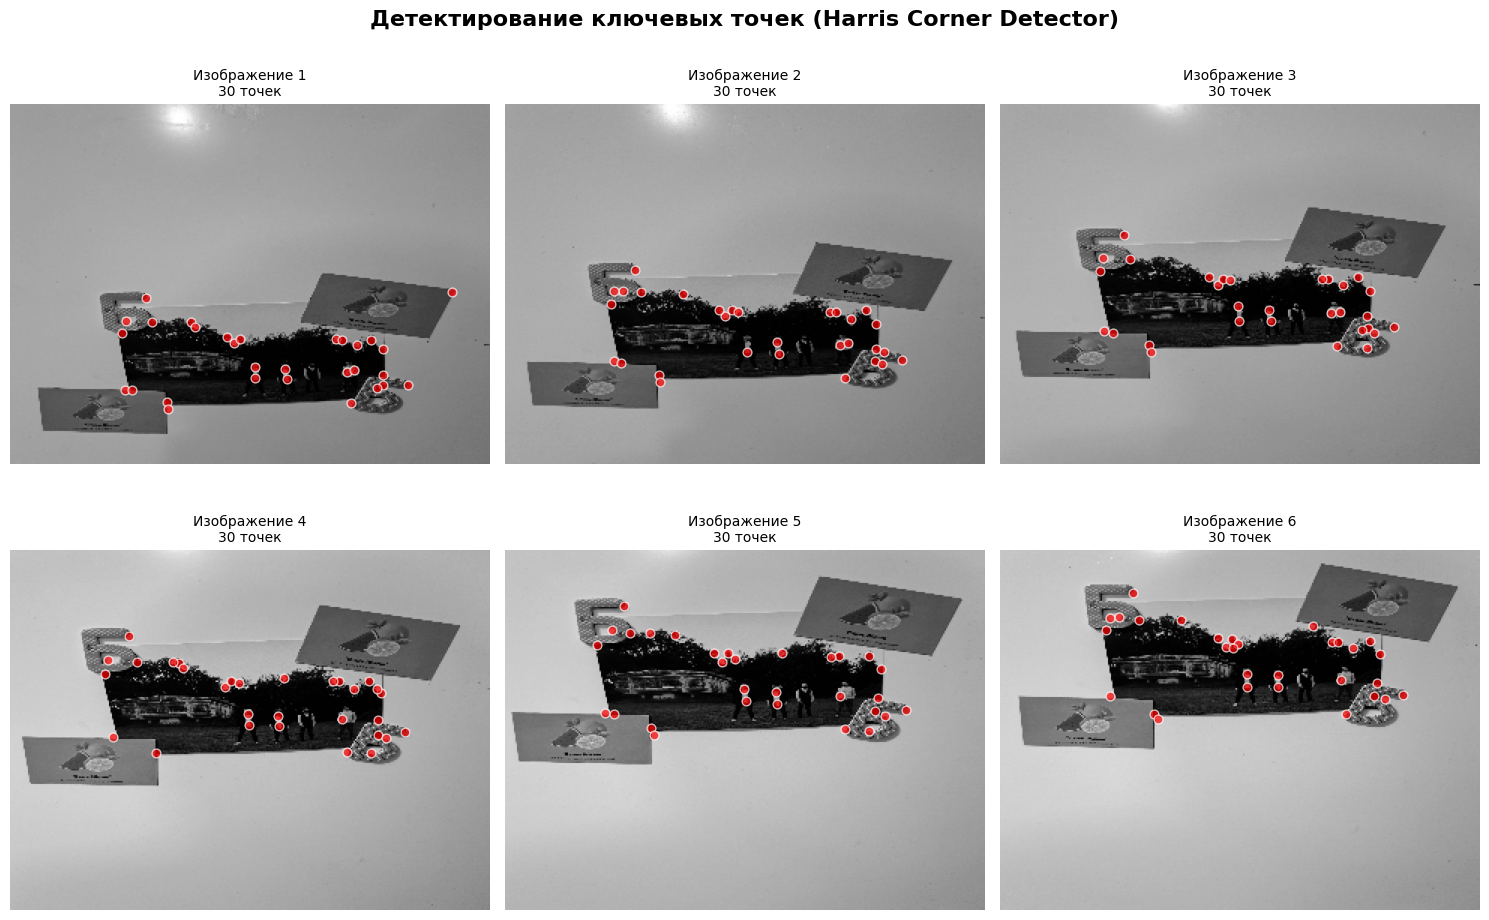

In [6]:
# ВИЗУАЛИЗАЦИЯ 1: Ключевые точки (с сохранением отдельных файлов)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Детектирование ключевых точек (Harris Corner Detector)', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(images_gray):
        ax.imshow(images_gray[i], cmap='gray')
        if len(all_corners[i]) > 0:
            ax.scatter(all_corners[i][:, 0], all_corners[i][:, 1], 
                      c='red', s=40, alpha=0.7, edgecolors='white', linewidths=1)
        ax.set_title(f'Изображение {i+1}\n{len(all_corners[i])} точек', fontsize=10)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.savefig('detect_all.png', dpi=300, bbox_inches='tight')  # Сохранение общего изображения
plt.show()

# Сохранение отдельных изображений
for i, img in enumerate(images_gray):
    fig_det, ax_det = plt.subplots(1, 1, figsize=(8, 6))
    ax_det.imshow(img, cmap='gray')
    if len(all_corners[i]) > 0:
        ax_det.scatter(all_corners[i][:, 0], all_corners[i][:, 1], 
                      c='red', s=40, alpha=0.7, edgecolors='white', linewidths=1)
    ax_det.set_title(f'Изображение {i+1} - {len(all_corners[i])} точек', fontsize=12)
    ax_det.axis('off')
    
    # Сохранение с именем detect_1, detect_2, и т.д.
    plt.savefig(f'detect_{i+1}.png', dpi=300, bbox_inches='tight')
    plt.close(fig_det)  # Закрываем фигуру, чтобы не занимать память

 # ШАГ 2: Ключевые точки SIFT

In [7]:
def compute_gradient_orientation(gx, gy):
    """Вычисление магнитуды и ориентации градиента"""
    magnitude = np.sqrt(gx**2 + gy**2)
    orientation = np.arctan2(gy, gx) * 180 / np.pi
    orientation[orientation < 0] += 360
    return magnitude, orientation


In [8]:

def compute_sift_descriptor(img, x, y, patch_size=16, num_bins=8):
    """
    Вычисление SIFT-подобного дескриптора для ключевой точки
    
    Параметры:
    img: изображение
    x, y: координаты ключевой точки
    patch_size: размер патча (16x16)
    num_bins: количество бинов в гистограмме (8)
    
    Возвращает:
    descriptor: вектор дескриптора (128 элементов)
    """
    half = patch_size // 2
    x, y = int(x), int(y)
    
    # Проверяем границы
    if (x < half or x >= img.shape[1] - half or 
        y < half or y >= img.shape[0] - half):
        return None
    
    # Извлекаем патч
    patch = img[y-half:y+half+1, x-half:x+half+1]
    
    # Вычисляем градиенты
    gx = cv.Sobel(patch, cv.CV_64F, 1, 0, ksize=3)
    gy = cv.Sobel(patch, cv.CV_64F, 0, 1, ksize=3)
    
    # Вычисляем магнитуду и ориентацию
    magnitude, orientation = compute_gradient_orientation(gx, gy)
    
    # Разбиваем патч на 4x4 подобласти (каждая 4x4 пикселя)
    cell_size = patch_size // 4  # 4
    descriptor = []
    
    for i in range(4):
        for j in range(4):
            # Извлекаем подобласть
            cell_mag = magnitude[i*cell_size:(i+1)*cell_size, 
                                 j*cell_size:(j+1)*cell_size]
            cell_ori = orientation[i*cell_size:(i+1)*cell_size, 
                                   j*cell_size:(j+1)*cell_size]
            
            # Вычисляем гистограмму ориентаций для подобласти
            hist = np.zeros(num_bins)
            bin_width = 360 / num_bins
            
            for m in range(cell_size):
                for n in range(cell_size):
                    bin_idx = int(cell_ori[m, n] / bin_width) % num_bins
                    hist[bin_idx] += cell_mag[m, n]
            
            # Нормализуем гистограмму
            hist_norm = hist / (np.linalg.norm(hist) + 1e-6)
            
            # Ограничиваем значения (как в SIFT)
            hist_clipped = np.clip(hist_norm, 0, 0.2)
            
            # Перенормировка
            if np.linalg.norm(hist_clipped) > 0:
                hist_final = hist_clipped / np.linalg.norm(hist_clipped)
            else:
                hist_final = hist_clipped
            
            descriptor.extend(hist_final)
    
    return np.array(descriptor)


In [9]:
def gaussian_kernel(size, sigma=1.0):
    """Создание гауссова ядра"""
    kernel = np.zeros((size, size))
    center = size // 2
    
    for i in range(size):
        for j in range(size):
            x = i - center
            y = j - center
            kernel[i, j] = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    
    kernel = kernel / np.sum(kernel)
    return kernel

In [10]:

def build_scale_space(img, num_octaves=3, num_scales=3, sigma=1.6):
    """Построение масштабного пространства (для полноты SIFT)"""
    scale_space = []
    k = 2 ** (1.0 / num_scales)
    
    for octave in range(num_octaves):
        octave_images = []
        if octave == 0:
            current_img = img.astype(np.float64)
        else:
            current_img = cv.resize(octave_images[0], None, fx=0.5, fy=0.5)
        
        for scale in range(num_scales + 3):
            current_sigma = sigma * (k ** scale)
            kernel_size = int(6 * current_sigma) + 1
            if kernel_size % 2 == 0:
                kernel_size += 1
            
            kernel = gaussian_kernel(kernel_size, current_sigma)
            blurred = cv.filter2D(current_img, -1, kernel)
            octave_images.append(blurred)
        
        scale_space.append(octave_images)
    
    return scale_space

# Вычисляем дескрипторы для всех ключевых точек
all_descriptors = []
valid_corners = []

print("📊 Вычисление дескрипторов для каждой ключевой точки:")

for i, img in enumerate(images_gray):
    img_descriptors = []
    img_valid_corners = []
    
    for j, (x, y) in enumerate(all_corners[i]):
        descriptor = compute_sift_descriptor(img, x, y, patch_size=16)
        if descriptor is not None:
            img_descriptors.append(descriptor)
            img_valid_corners.append((x, y))
    
    all_descriptors.append(np.array(img_descriptors) if img_descriptors else np.array([]))
    valid_corners.append(np.array(img_valid_corners))
    print(f"   Изображение {i+1}: {len(img_descriptors)} валидных дескрипторов")


📊 Вычисление дескрипторов для каждой ключевой точки:
   Изображение 1: 30 валидных дескрипторов
   Изображение 2: 30 валидных дескрипторов
   Изображение 3: 30 валидных дескрипторов
   Изображение 4: 30 валидных дескрипторов
   Изображение 5: 30 валидных дескрипторов
   Изображение 6: 30 валидных дескрипторов


#  ШАГ 3: Построение траектории

In [11]:
def match_descriptors(desc1, desc2, ratio_thresh=0.75):
    """
    Сопоставление дескрипторов с использованием Lowe's ratio test
    
    Параметры:
    desc1, desc2: массивы дескрипторов
    ratio_thresh: порог для ratio test (обычно 0.7-0.8)
    
    Возвращает:
    matches: список сопоставлений (idx1, idx2, distance)
    """
    if len(desc1) == 0 or len(desc2) == 0:
        return []
    
    matches = []
    
    for i in range(len(desc1)):
        # Вычисляем расстояния до всех дескрипторов во втором изображении
        distances = np.linalg.norm(desc2 - desc1[i], axis=1)
        
        # Находим два наименьших расстояния
        if len(distances) >= 2:
            sorted_idx = np.argsort(distances)
            d1 = distances[sorted_idx[0]]
            d2 = distances[sorted_idx[1]]
            
            # Lowe's ratio test
            if d1 < ratio_thresh * d2:
                matches.append((i, sorted_idx[0], d1))
    
    return matches


📊 Результаты сопоставления:
   Пара 1-2: 13 сопоставленных точек
   Пара 2-3: 17 сопоставленных точек
   Пара 3-4: 13 сопоставленных точек
   Пара 4-5: 16 сопоставленных точек
   Пара 5-6: 15 сопоставленных точек


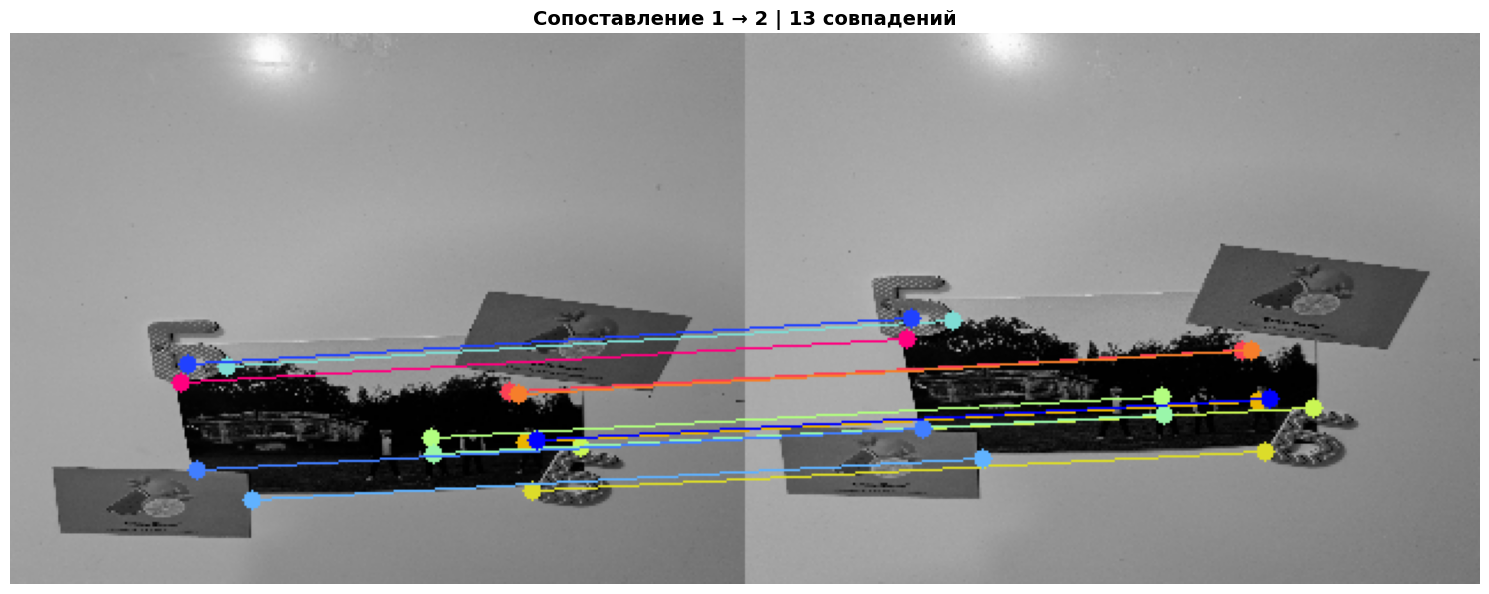

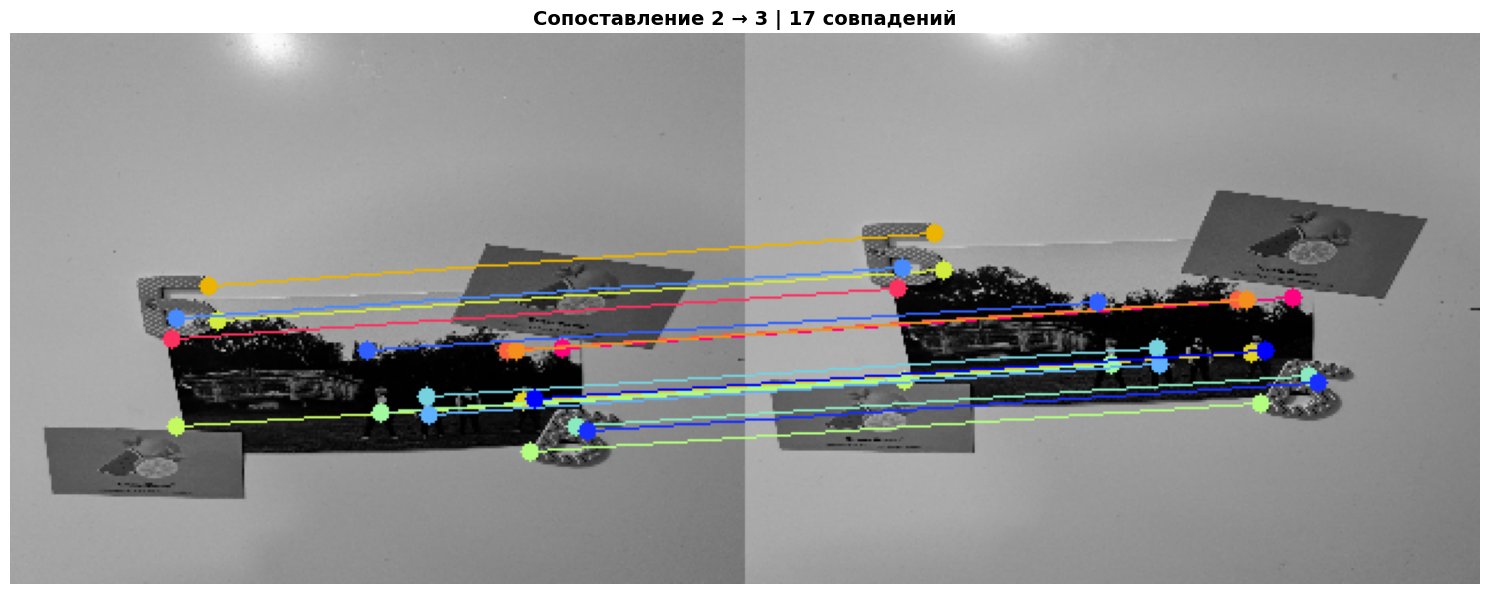

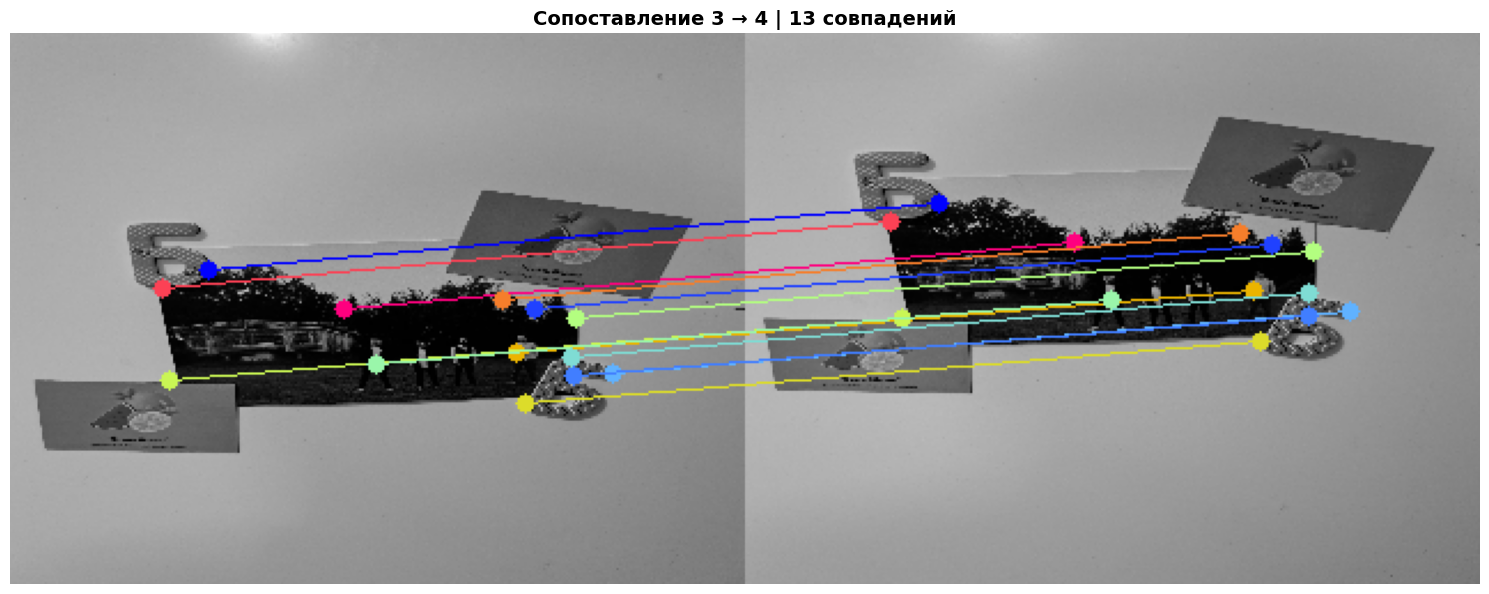

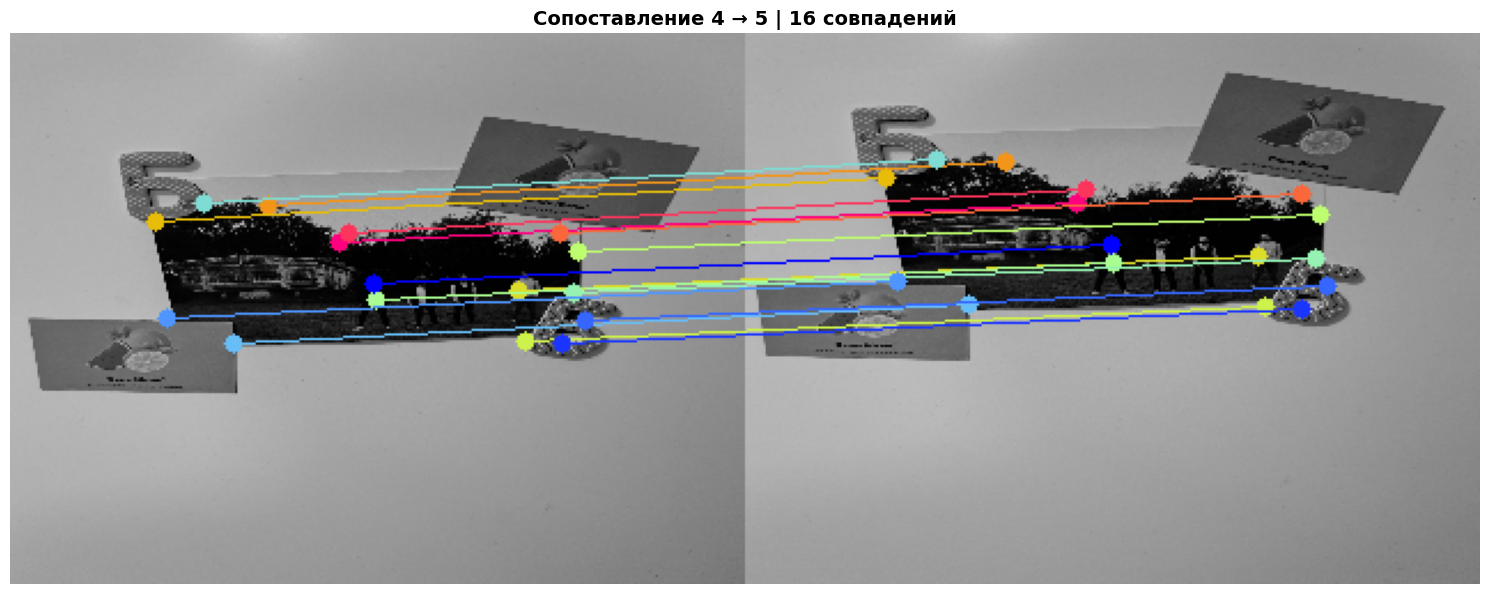

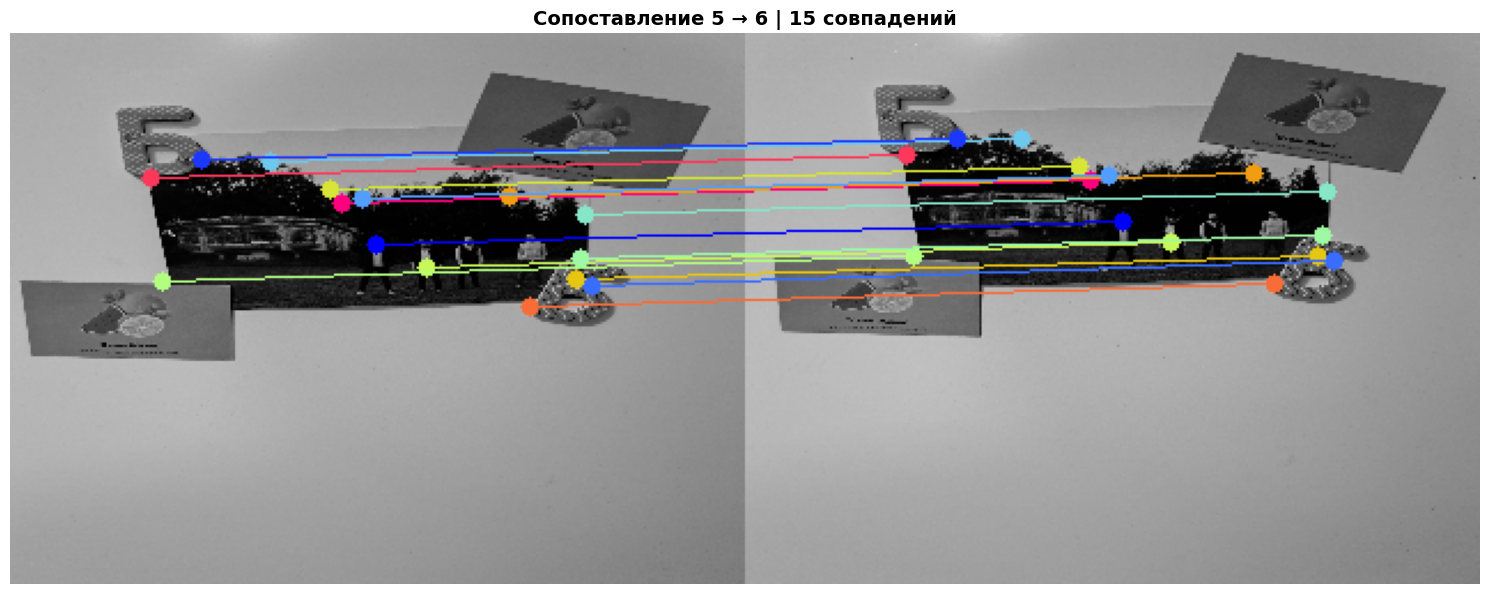

In [13]:



# Сопоставляем соседние изображения
all_matches = []
print("\n📊 Результаты сопоставления:")

for i in range(len(images_gray) - 1):
    if len(all_descriptors[i]) > 0 and len(all_descriptors[i+1]) > 0:
        matches = match_descriptors(all_descriptors[i], all_descriptors[i+1])
        all_matches.append(matches)
        print(f"   Пара {i+1}-{i+2}: {len(matches)} сопоставленных точек")
    else:
        all_matches.append([])
        print(f"   Пара {i+1}-{i+2}: нет дескрипторов для сопоставления")

# Функция для визуализации сопоставлений
def visualize_matches(img1, img2, corners1, corners2, matches, title=""):
    """Визуализация сопоставленных точек"""
    if len(matches) == 0:
        print("   Нет сопоставлений для визуализации")
        return
    
    h1, w1 = img1.shape
    h2, w2 = img2.shape
    
    # Создаем объединенное изображение
    combined = np.zeros((max(h1, h2), w1 + w2), dtype=np.uint8)
    combined[:h1, :w1] = img1
    combined[:h2, w1:w1+w2] = img2
    
    # Конвертируем в цветное
    combined_color = cv.cvtColor(combined, cv.COLOR_GRAY2BGR)
    
    # Рисуем сопоставления
    colors = plt.cm.rainbow(np.linspace(0, 1, min(20, len(matches))))
    
    for idx, (i, j, dist) in enumerate(matches[:20]):  # Первые 20
        color = tuple(int(c * 255) for c in colors[idx][:3])
        
        x1, y1 = corners1[i]
        x2, y2 = corners2[j]
        
        # Рисуем точки
        cv.circle(combined_color, (int(x1), int(y1)), 4, color, -1)
        cv.circle(combined_color, (int(x2) + w1, int(y2)), 4, color, -1)
        
        # Рисуем линию
        cv.line(combined_color, (int(x1), int(y1)), 
                (int(x2) + w1, int(y2)), color, 1)
    
    plt.figure(figsize=(15, 6))
    plt.imshow(cv.cvtColor(combined_color, cv.COLOR_BGR2RGB))
    plt.title(f'{title} | {len(matches)} совпадений', fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# ВИЗУАЛИЗАЦИЯ 2: Сопоставление точек
for i, matches in enumerate(all_matches):
    if len(matches) > 0:
        visualize_matches(images_gray[i], images_gray[i+1], 
                         valid_corners[i], valid_corners[i+1], 
                         matches, f'Сопоставление {i+1} → {i+2}')


# ШАГ 4: Визуализация траектории

In [15]:

def estimate_transform(matches, corners1, corners2):
    """
    Оценка аффинного преобразования методом наименьших квадратов
    
    Параметры:
    matches: список сопоставлений (idx1, idx2, distance)
    corners1, corners2: координаты ключевых точек
    
    Возвращает:
    matrix: матрица преобразования 2x3
    translation: вектор смещения (dx, dy)
    """
    if len(matches) < 3:
        return None, (0, 0)
    
    # Собираем соответствующие точки
    pts1 = []
    pts2 = []
    
    for i, j, _ in matches:
        pts1.append(corners1[i])
        pts2.append(corners2[j])
    
    pts1 = np.array(pts1)
    pts2 = np.array(pts2)
    
    # Вычисляем среднее смещение
    translation = np.mean(pts2 - pts1, axis=0)
    
    # Для аффинного преобразования нужна матрица 2x3
    # Но для простоты используем только смещение
    matrix = np.array([[1, 0, translation[0]],
                       [0, 1, translation[1]]])
    
    return matrix, translation

In [16]:


def ransac_transform(matches, corners1, corners2, n_iterations=100, threshold=10.0):
    """
    Оценка преобразования с использованием RANSAC
    
    Параметры:
    matches: список сопоставлений
    corners1, corners2: координаты ключевых точек
    n_iterations: количество итераций RANSAC
    threshold: порог для определения inliers
    
    Возвращает:
    best_transform: лучшая матрица преобразования
    best_translation: лучшее смещение
    best_inliers: индексы inliers
    """
    if len(matches) < 3:
        return None, (0, 0), []
    
    best_inliers = []
    best_translation = (0, 0)
    
    for _ in range(n_iterations):
        # Выбираем 3 случайных сопоставления
        sample_idx = random.sample(range(len(matches)), 3)
        sample_matches = [matches[i] for i in sample_idx]
        
        # Оцениваем преобразование
        _, translation = estimate_transform(sample_matches, corners1, corners2)
        
        # Находим inliers
        inliers = []
        for idx, (i, j, _) in enumerate(matches):
            x1, y1 = corners1[i]
            x2, y2 = corners2[j]
            
            # Вычисляем ошибку
            error = np.sqrt((x2 - x1 - translation[0])**2 + 
                          (y2 - y1 - translation[1])**2)
            
            if error < threshold:
                inliers.append(idx)
        
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_translation = translation
    
    # Переоцениваем по всем inliers
    if len(best_inliers) >= 3:
        inlier_matches = [matches[i] for i in best_inliers]
        _, best_translation = estimate_transform(inlier_matches, corners1, corners2)
    
    best_matrix = np.array([[1, 0, best_translation[0]],
                           [0, 1, best_translation[1]]])
    
    return best_matrix, best_translation, best_inliers

# Оцениваем преобразования между соседними изображениями
trajectory = [(0, 0)]
transformations = []

print("\n📊 Оценка смещений между кадрами (с RANSAC):")

for i, matches in enumerate(all_matches):
    if len(matches) >= 3:
        matrix, translation, inliers = ransac_transform(
            matches, valid_corners[i], valid_corners[i+1]
        )
        
        last_point = trajectory[-1]
        new_point = (last_point[0] + translation[0], 
                    last_point[1] + translation[1])
        trajectory.append(new_point)
        transformations.append(matrix)
        
        print(f"   Кадр {i+1} → {i+2}:")
        print(f"      Смещение: Δx = {translation[0]:.2f}, Δy = {translation[1]:.2f}")
        print(f"      Inliers: {len(inliers)}/{len(matches)}")
        print(f"      Позиция: ({new_point[0]:.2f}, {new_point[1]:.2f})")
    else:
        trajectory.append(trajectory[-1])
        transformations.append(None)
        print(f"   Кадр {i+1} → {i+2}: недостаточно совпадений ({len(matches)})")


📊 Оценка смещений между кадрами (с RANSAC):
   Кадр 1 → 2:
      Смещение: Δx = -2.23, Δy = -18.23
      Inliers: 13/13
      Позиция: (-2.23, -18.23)
   Кадр 2 → 3:
      Смещение: Δx = -2.53, Δy = -21.53
      Inliers: 17/17
      Позиция: (-4.76, -39.76)
   Кадр 3 → 4:
      Смещение: Δx = -0.15, Δy = -27.92
      Inliers: 13/13
      Позиция: (-4.91, -67.68)
   Кадр 4 → 5:
      Смещение: Δx = 1.12, Δy = -16.69
      Inliers: 16/16
      Позиция: (-3.79, -84.37)
   Кадр 5 → 6:
      Смещение: Δx = 5.20, Δy = -10.13
      Inliers: 15/15
      Позиция: (1.41, -94.50)



🔍 ШАГ 5: Построение траектории движения камеры
------------------------------------------------------------
✅ Картинка траектории сохранена: траектория_камеры.png (300 DPI)


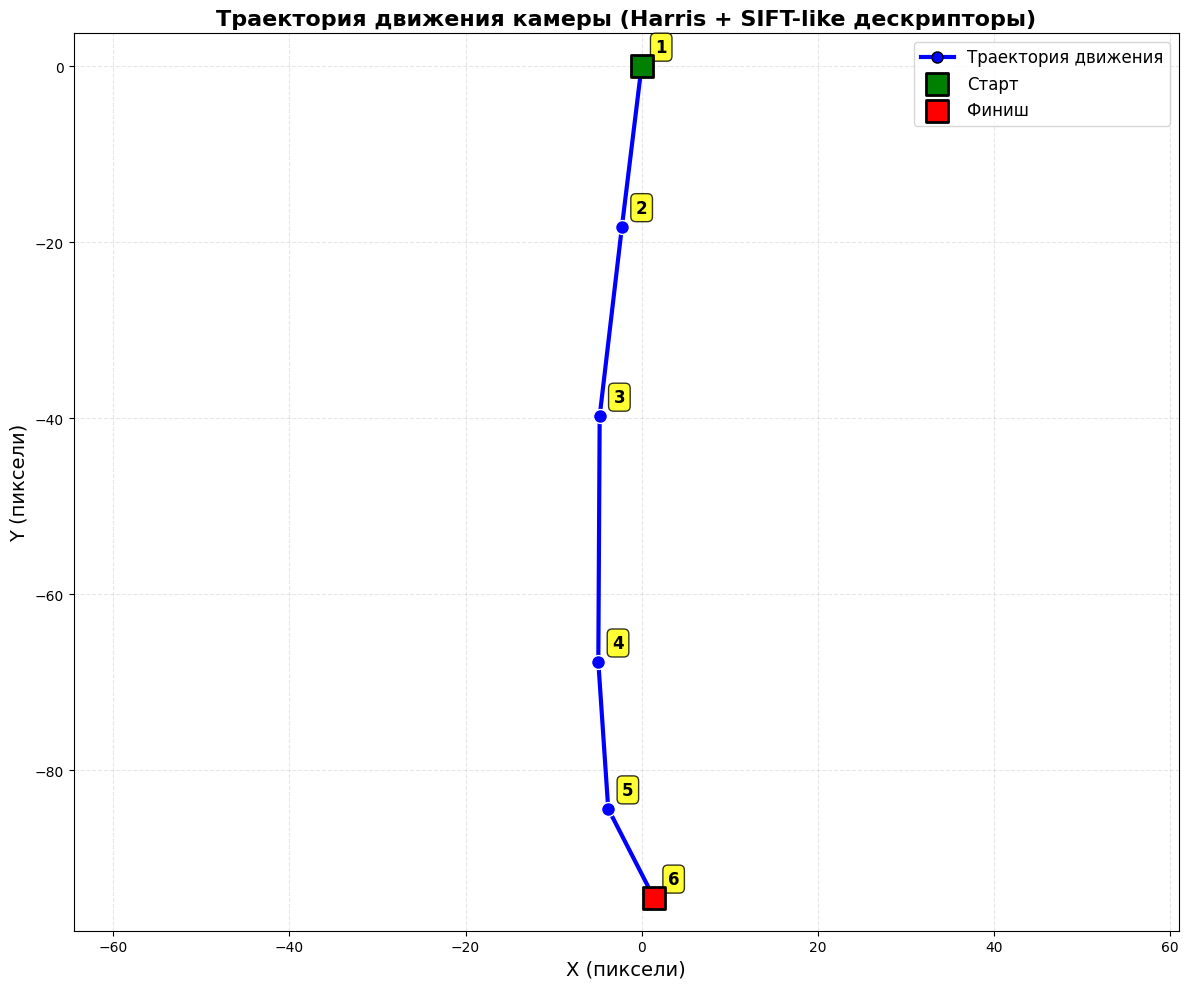

In [18]:
print("\n🔍 ШАГ 5: Построение траектории движения камеры")
print("-"*60)

# ВИЗУАЛИЗАЦИЯ 3: Траектория
trajectory_np = np.array(trajectory)  # Преобразуем в numpy массив

plt.figure(figsize=(12, 10))

# Рисуем траекторию
plt.plot(trajectory_np[:, 0], trajectory_np[:, 1], 'b-o', linewidth=3, markersize=8, 
         label='Траектория движения', markeredgecolor='black', markeredgewidth=1)

# Отмечаем точки
plt.scatter(trajectory_np[0, 0], trajectory_np[0, 1], c='green', s=250, 
            marker='s', label='Старт', edgecolors='black', linewidth=2, zorder=5)
plt.scatter(trajectory_np[-1, 0], trajectory_np[-1, 1], c='red', s=250, 
            marker='s', label='Финиш', edgecolors='black', linewidth=2, zorder=5)

# Добавляем промежуточные точки
plt.scatter(trajectory_np[1:-1, 0], trajectory_np[1:-1, 1], c='blue', s=100, 
            edgecolors='white', linewidth=1, zorder=4)

# Добавляем номера кадров
for i, (x, y) in enumerate(trajectory_np):
    plt.annotate(f'{i+1}', (x, y), xytext=(10, 10), 
                textcoords='offset points', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8, edgecolor='black'))

plt.grid(True, alpha=0.3, linestyle='--')
plt.xlabel('X (пиксели)', fontsize=14)
plt.ylabel('Y (пиксели)', fontsize=14)
plt.title('Траектория движения камеры (Harris + SIFT-like дескрипторы)', fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc='best')
plt.axis('equal')
plt.tight_layout()

# ✅ СОХРАНЕНИЕ КАРТИНКИ ТРАЕКТОРИИ
plt.savefig('trajectory.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

plt.show()
